# Data Overview

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
import numpy as np
import json
from utils import *
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib import patches
from tqdm import tqdm
import torch
import torchvision.transforms as transforms
from hirise_dtm import HiriseDTM

data_path = "data"
cave_catalog_path = os.path.join(data_path, "Mars_Extended_Cave_Catalog.csv")
deeplandforms_path = os.path.join(data_path, "DeepLandforms_dataset", "dataset.json")

## Mars Global Cave Candidate Catalog (MGC^3)

Integrated with elevations taken with pygmt: https://www.pygmt.org/latest/

G. E. Cushing. (2015). Mars Global Cave Candidate Catalog PDS4 Archive Bundle.  PDS Cartography and Imaging Sciences Node (IMG). https://doi.org/10.17189/1519222

In [2]:
cave_catalog = pd.read_csv(cave_catalog_path)
cave_catalog

,label,longitude,latitude,TypeCode,Priority,APC_Diameter,APC_Depth,Comment,elevation
0,APC001,240.4585,-0.94678,APC,1,25,32.0,APC -- tiny ~25m,5845.516289
1,APC003,237.6960,-12.47266,APC,1,30,47.0,APC 40m small deep nochain--big smrp?,10500.439389
2,APC005,240.8867,-5.68445,APC,1,30,17.0,APC deep pair,10144.570834
3,APC006,240.9421,-1.61377,APC,1,40,38.0,APC small deep?,6446.123804
4,APC007,241.2993,-1.68555,APC,1,40,28.0,"APC, deep? ~40m",6610.563531
...,...,...,...,...,...,...,...,...,...
1057,CC0926,161.1272,9.64587,crk,0,NaN,NaN,Cerberus fractures in HiRISE,-2767.424452
1058,CC0927,141.3146,30.56317,irr,0,NaN,NaN,Irregular surface hole,-1519.403413
1059,CC0928,141.3121,30.58740,crk,0,NaN,NaN,Small ambiguous hole in fracture,-1559.675572
1060,CC0929,242.9741,-0.26598,sky,1,NaN,NaN,"pair of 60-m pits in flow, 1km apart",6403.049279


## DeepLandforms

Source: https://zenodo.org/records/6818611?preview_file=DeepLandforms_demo_dataset.zip

In [3]:
with open(deeplandforms_path, 'r') as json_file:
    deep_landforms_metadata = json.load(json_file)
    deep_landforms_metadata_imgs = pd.DataFrame(deep_landforms_metadata["images"])
    deep_landforms_metadata_annotations = pd.DataFrame(deep_landforms_metadata["annotations"])
    deep_landforms_metadata_categories = pd.DataFrame(deep_landforms_metadata["categories"])

deep_landforms_metadata_imgs

,height,width,id,file_name
0,1728,1729,1,ESP_011386_2065_RED_resized_0.5_lbl_0.tiff
1,2116,2116,2,ESP_011386_2065_RED_resized_0.5_lbl_1.tiff
2,1212,1212,3,ESP_011386_2065_RED_resized_1_lbl_0.tiff
3,1540,1540,4,ESP_011386_2065_RED_resized_1_lbl_1.tiff
4,1008,1008,5,ESP_011386_2065_RED_resized_2_lbl_0.tiff
...,...,...,...,...
1831,2170,2170,1832,PSP_005691_1685_RED_resized_1_lbl_2.tiff
1832,1306,1306,1833,PSP_005691_1685_RED_resized_1_lbl_3.tiff
1833,1094,1094,1834,PSP_005691_1685_RED_resized_2_lbl_0.tiff
1834,1032,1032,1835,PSP_005691_1685_RED_resized_2_lbl_1.tiff


In [4]:
deep_landforms_metadata_annotations


,iscrowd,image_id,bbox,segmentation,category_id,id,area
0,0,1,"[438, 449, 830, 799]","[[673, 458, 507, 581, 465, 694, 438, 821, 466,...",0,1,532485
1,0,2,"[523, 535, 1048, 1016]","[[935, 565, 1031, 543, 1145, 535, 1242, 570, 1...",1,2,806355
2,0,3,"[399, 407, 415, 399]","[[517, 411, 434, 473, 413, 529, 399, 593, 414,...",0,3,133052
3,0,4,"[508, 516, 524, 508]","[[714, 531, 762, 520, 819, 516, 867, 533, 903,...",1,4,201337
4,0,5,"[400, 404, 208, 200]","[[459, 406, 417, 437, 407, 465, 400, 497, 407,...",0,5,33296
...,...,...,...,...,...,...,...
1841,0,1832,"[719, 726, 732, 719]","[[738, 1184, 719, 1100, 736, 1022, 775, 922, 8...",1,1842,417164
1842,0,1833,"[420, 443, 467, 420]","[[420, 568, 476, 505, 534, 474, 558, 450, 629,...",1,1843,137967
1843,0,1834,"[421, 378, 252, 339]","[[425, 450, 436, 418, 464, 396, 487, 391, 501,...",2,1844,57638
1844,0,1835,"[352, 328, 328, 377]","[[394, 380, 414, 359, 458, 346, 493, 338, 548,...",1,1845,90816


In [5]:
deep_landforms_metadata_categories

,id,name,supercategory
0,0,Type-1,Type-1
1,1,Type-4,Type-4
2,2,Type-2,Type-2


In [6]:
counts = deep_landforms_metadata_annotations["category_id"].value_counts()
map = {0: "Crater", 1: "Pit", 2:"Chain of Craters"}

print("LABEL COUNT")
for category_id, count in counts.items():
    label = map.get(category_id, "Unknown")
    print(f"{label}: {count}")

LABEL COUNT
Pit: 657
Crater: 625
Chain of Craters: 564


In [7]:
# Initialize variables to accumulate mean and std
mean = torch.zeros(1)
std = torch.zeros(1)
num_pixels = 0

# Dictionary to keep track of image shapes
shapes = {}

# Loop through the global dataset
for _, row in tqdm(
    deep_landforms_metadata_imgs.iterrows(),
    desc="Collecting image dimensions and computing statistics",
    total=len(deep_landforms_metadata_imgs)
):
    img = Image.open(os.path.join("data", f'DeepLandforms_dataset/{row["file_name"]}'))

    transform = transforms.Compose([
        transforms.PILToTensor()
    ])

    img = transform(img).float()
    channels, height, width = img.shape

    # Update shape occurrences
    shape = (width, height)
    shapes[shape] = shapes.get(shape, 0) + 1

    # Compute the number of pixels per image
    num_pixels += height * width

    # Sum the mean values of each channel
    mean += img.view(channels, -1).mean(dim=1)

    # Sum the standard deviation of each channel
    std += img.view(channels, -1).std(dim=1)


# Divide the sum of means and std by the total number of images
mean /= len(deep_landforms_metadata_imgs)
std /= len(deep_landforms_metadata_imgs)


# Find smallest and biggest images based on total pixel count
smallest_shape = min(shapes, key=lambda s: s[0] * s[1])
biggest_shape = max(shapes, key=lambda s: s[0] * s[1])

######## Probability distribution of image size over dataset ########
size_counts = {shape[0]: count for shape, count in shapes.items()}

sizes = list(size_counts.keys())
counts = list(size_counts.values())
sum_counts = sum(counts)

probabilities = [count/sum_counts for count in counts]
size_probability_dist = {size: prob for size, prob in zip(sizes, probabilities)}


print("Mean and standard deviation of image channels:")
print(f"Mean: {mean}")
print(f"Std: {std}")

print("\nImage dimensions:")
print(f"Smallest image: {smallest_shape} "
      f"({smallest_shape[0] * smallest_shape[1]:,} pixels)")

print(f"Biggest image: {biggest_shape} "
      f"({biggest_shape[0] * biggest_shape[1]:,} pixels)")

print(f"Number of different image sizes: {len(shapes)}")

Mean and standard deviation of image channels:
Mean: tensor([139.3476])
Std: tensor([28.8609])

Image dimensions:
Smallest image: (146, 146) (21,316 pixels)
Biggest image: (3465, 3465) (12,006,225 pixels)
Number of different image sizes: 753


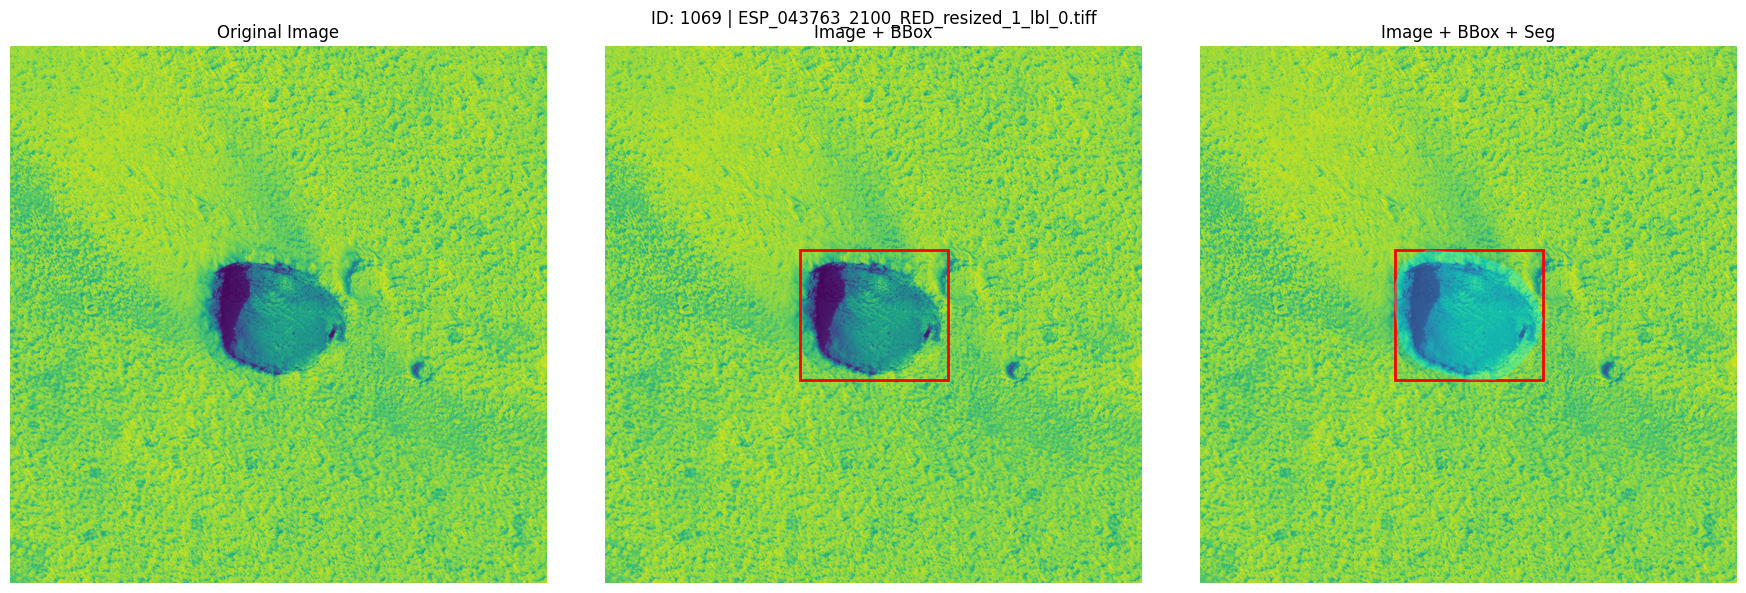

In [8]:
deep_landforms_metadata_annotations_copy = deep_landforms_metadata_annotations[deep_landforms_metadata_annotations["category_id"] == 0]
deep_landforms_metadata_annotations_copy.reset_index(inplace=True)

random_id = np.random.randint(len(deep_landforms_metadata_annotations_copy))
random_id = deep_landforms_metadata_annotations_copy.loc[random_id, "image_id"]

image_name = deep_landforms_metadata_imgs.loc[deep_landforms_metadata_imgs["id"] == random_id]["file_name"].item()
img_annotations = deep_landforms_metadata_annotations_copy.loc[deep_landforms_metadata_annotations_copy["image_id"] == random_id]

if img_annotations.empty:
    print(f"No annotations found for image ID {random_id}")

bounding_box = img_annotations["bbox"].iloc[0]
segmentation = img_annotations["segmentation"].iloc[0]

example = Image.open(f'data/DeepLandforms_dataset/{image_name}')
with open(f'data/DeepLandforms_dataset/{image_name.replace(".tiff", ".json")}') as json_file:
    example_json = json.load(json_file)
#print(example_json)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(example)
axs[0].set_title("Original Image")

axs[1].imshow(example)
x_min, y_min, width, height = bounding_box
rect = patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor='red', facecolor='none')
axs[1].add_patch(rect)
axs[1].set_title("Image + BBox")

axs[2].imshow(example)
rect2 = patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor='red', facecolor='none')
axs[2].add_patch(rect2)
if isinstance(segmentation, list):
    for sub_polygon in segmentation:
        poly_coords = np.array(sub_polygon).reshape(-1, 2)
        polygon = patches.Polygon(poly_coords, closed=True, linewidth=1, edgecolor='cyan', facecolor='cyan', alpha=0.3)
        axs[2].add_patch(polygon)
axs[2].set_title("Image + BBox + Seg")

for ax in axs:
    ax.axis('off')

plt.suptitle(f"ID: {random_id} | {image_name}")
plt.tight_layout()
plt.show()

Shape: (930, 930)


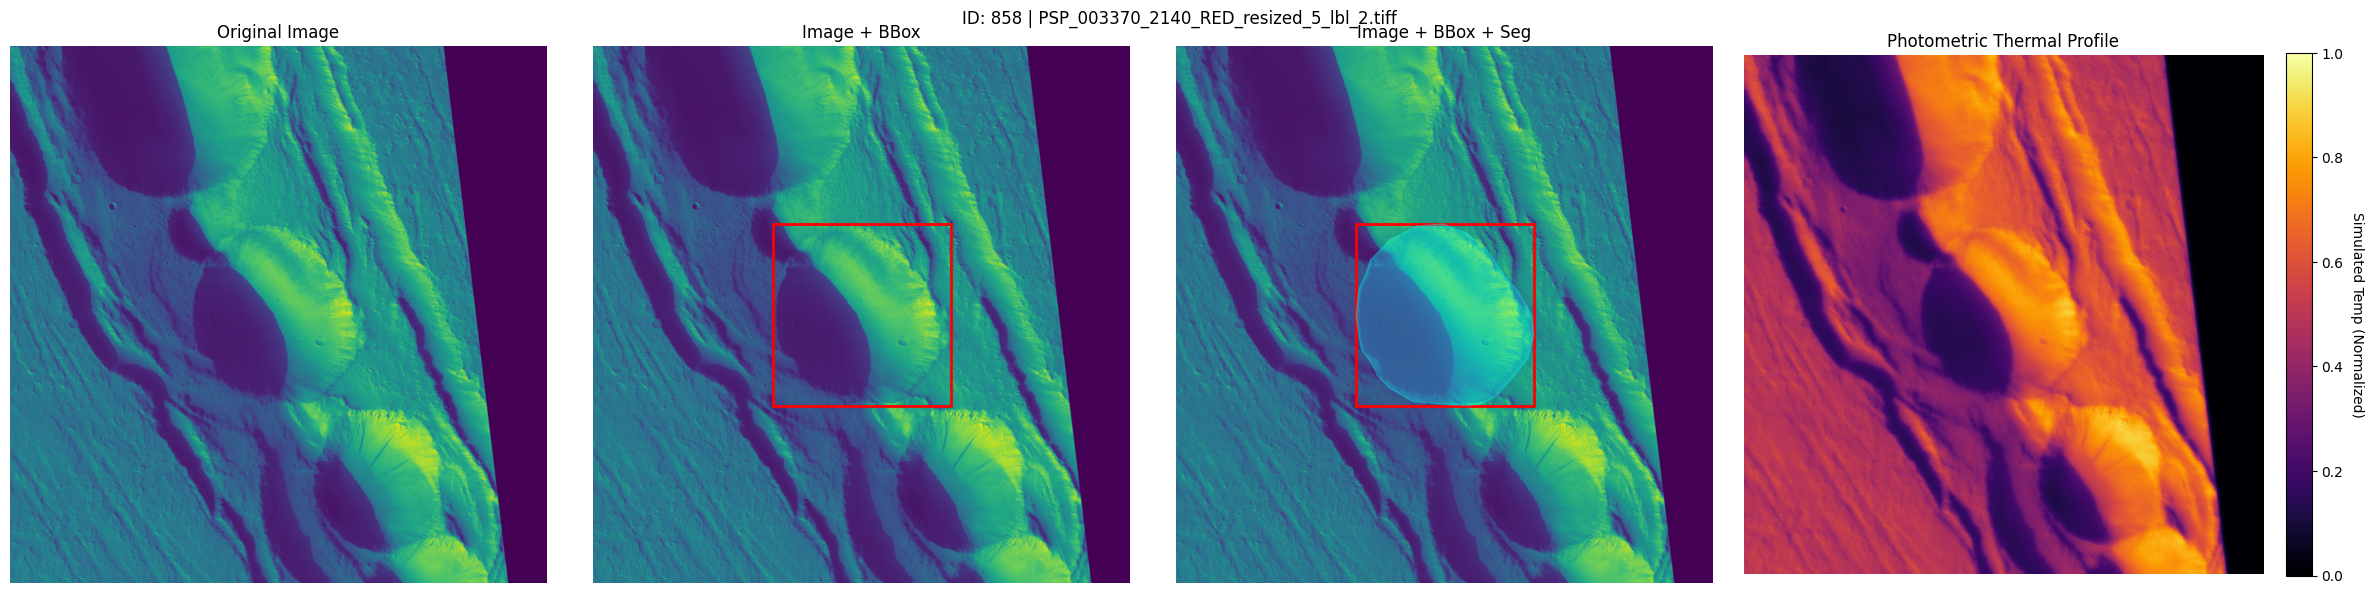

In [9]:
import json
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.ndimage import gaussian_filter

# --- [Assuming dataset metadata dataframes are already loaded] ---

random_id = np.random.randint(len(deep_landforms_metadata_annotations))
image_name = deep_landforms_metadata_imgs.loc[
    deep_landforms_metadata_imgs["id"] == random_id
]["file_name"].item()
img_annotations = deep_landforms_metadata_annotations.loc[
    deep_landforms_metadata_annotations["image_id"] == random_id
]

if img_annotations.empty:
    print(f"No annotations found for image ID {random_id}")

bounding_box = img_annotations["bbox"].iloc[0]
segmentation = img_annotations["segmentation"].iloc[0]

example = Image.open(f"data/DeepLandforms_dataset/{image_name}")
with open(
    f'data/DeepLandforms_dataset/{image_name.replace(".tiff", ".json")}'
) as json_file:
    example_json = json.load(json_file)

# ---------------------------------------------------------
# 1. MASK-INDEPENDENT THERMAL SYNTHESIS
# ---------------------------------------------------------
gray_light = np.array(example.convert("L"), dtype=np.float32) / 255.0
print(f"Shape: {gray_light.shape}")

# A. Non-linear Radiative Response:
# Sunlit terrain (high light) reaches high surface temps (~0.85-1.0).
# Shallow illuminated craters stay moderately warm (~0.5-0.7).
# Deep, dark shadows (low light) drop to cold thermal baselines (~0.15-0.3).
radiative_temp = np.power(gray_light, 0.75)

# B. Thermal Diffusion (Heat Conduction):
# Thermal infrared images have lower spatial frequencies than optical images.
# Blurring simulates conductive heat spreading into adjacent regolith and shadows.
thermal_diffused = gaussian_filter(radiative_temp, sigma=4.0)

# C. Detail Preservation & Sensor Noise:
# Combine 70% diffuse thermal field with 30% local detail + sensor noise
noise = np.random.normal(0, 0.012, gray_light.shape)
thermal_synth = np.clip(0.70 * thermal_diffused + 0.30 * radiative_temp + noise, 0, 1)

# ---------------------------------------------------------
# 2. PLOT ALL 4 SUBPLOTS
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 4, figsize=(24, 6))

# Subplot 1: Original Image
axs[0].imshow(example)
axs[0].set_title("Original Image")

# Subplot 2: Image + Bounding Box
axs[1].imshow(example)
x_min, y_min, width, height = bounding_box
rect = patches.Rectangle(
    (x_min, y_min), width, height, linewidth=2, edgecolor="red", facecolor="none"
)
axs[1].add_patch(rect)
axs[1].set_title("Image + BBox")

# Subplot 3: Image + Bounding Box + Segmentation
axs[2].imshow(example)
rect2 = patches.Rectangle(
    (x_min, y_min), width, height, linewidth=2, edgecolor="red", facecolor="none"
)
axs[2].add_patch(rect2)
if isinstance(segmentation, list):
    for sub_polygon in segmentation:
        poly_coords = np.array(sub_polygon).reshape(-1, 2)
        polygon = patches.Polygon(
            poly_coords,
            closed=True,
            linewidth=1,
            edgecolor="cyan",
            facecolor="cyan",
            alpha=0.3,
        )
        axs[2].add_patch(polygon)
axs[2].set_title("Image + BBox + Seg")

# Subplot 4: Image-Driven Thermal Profile
im4 = axs[3].imshow(thermal_synth, cmap="inferno", vmin=0, vmax=1)
axs[3].set_title("Photometric Thermal Profile")

# Colorbar Legend
cbar = fig.colorbar(im4, ax=axs[3], fraction=0.046, pad=0.04)
cbar.set_label("Simulated Temp (Normalized)", rotation=270, labelpad=15)

for ax in axs:
    ax.axis("off")

plt.suptitle(f"ID: {random_id} | {image_name}")
plt.tight_layout()
plt.show()


## Plain Terrain

In [23]:
plain_terrain_annotations = pd.read_csv("data/plain_terrain_dataset/plain_terrain_annotations.csv")
plain_terrain_annotations

,iscrowd,image_id,bbox,segmentation,category_id,id,area,file_name,crop_file,pixel_y,pixel_x,size,lat_center,lon_center,lat_topleft,lon_topleft,proj_x_center_m,proj_y_center_m,crs,label
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ESP_011335_1005_RED,ESP_011335_1005_RED_y28562_x4657_s502.tif,28562.0,4657.0,502.0,-79.710473,234.609038,-79.708170,234.601634,-507872.25,-359293.75,"PROJCS[""Polar_Stereographic MARS"",GEOGCS[""GCS_...",plain_terrain
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ESP_011335_1005_RED,ESP_011335_1005_RED_y4270_x26464_s1056.tif,4270.0,26464.0,1056.0,-79.490180,235.260464,-79.485337,235.244890,-496830.25,-347286.25,"PROJCS[""Polar_Stereographic MARS"",GEOGCS[""GCS_...",plain_terrain
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ESP_011335_1005_RED,ESP_011335_1005_RED_y9938_x20638_s1032.tif,9938.0,20638.0,1032.0,-79.542064,235.088257,-79.537330,235.073036,-499749.25,-350114.25,"PROJCS[""Polar_Stereographic MARS"",GEOGCS[""GCS_...",plain_terrain
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ESP_011335_1005_RED,ESP_011335_1005_RED_y22969_x4905_s937.tif,22969.0,4905.0,937.0,-79.661158,234.622754,-79.656865,234.608949,-507639.75,-356605.75,"PROJCS[""Polar_Stereographic MARS"",GEOGCS[""GCS_...",plain_terrain
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ESP_011335_1005_RED,ESP_011335_1005_RED_y17668_x7950_s1280.tif,17668.0,7950.0,1280.0,-79.614109,234.717648,-79.608238,234.698769,-506031.25,-354041.25,"PROJCS[""Polar_Stereographic MARS"",GEOGCS[""GCS_...",plain_terrain
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ESP_011335_1005_RED,ESP_011335_1005_RED_y24071_x9313_s1208.tif,24071.0,9313.0,1208.0,-79.672515,234.756791,-79.666974,234.738975,-505367.75,-357224.75,"PROJCS[""Polar_Stereographic MARS"",GEOGCS[""GCS_...",plain_terrain
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ESP_011335_1005_RED,ESP_011335_1005_RED_y7961_x24810_s1028.tif,7961.0,24810.0,1028.0,-79.523910,235.211262,-79.519195,235.196101,-497664.25,-349124.75,"PROJCS[""Polar_Stereographic MARS"",GEOGCS[""GCS_...",plain_terrain
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ESP_011335_1005_RED,ESP_011335_1005_RED_y25157_x2313_s3259.tif,25157.0,2313.0,3259.0,-79.691879,234.580543,-79.676936,234.532491,-508355.25,-358280.25,"PROJCS[""Polar_Stereographic MARS"",GEOGCS[""GCS_...",plain_terrain
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ESP_011335_1005_RED,ESP_011335_1005_RED_y9855_x22086_s1208.tif,9855.0,22086.0,1208.0,-79.542109,235.133565,-79.536569,235.115749,-498981.25,-350116.75,"PROJCS[""Polar_Stereographic MARS"",GEOGCS[""GCS_...",plain_terrain
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ESP_011335_1005_RED,ESP_011335_1005_RED_y7333_x27257_s1082.tif,7333.0,27257.0,1082.0,-79.518397,235.284240,-79.513434,235.268281,-496427.25,-348824.25,"PROJCS[""Polar_Stereographic MARS"",GEOGCS[""GCS_...",plain_terrain


## Digital Terrain Model (DTM)

{'product_type': 'Ortho Image', 'phase': 'ESP', 'orbit_number': '043599', 'latitude_band': '1650', 'band_color': 'RED'}


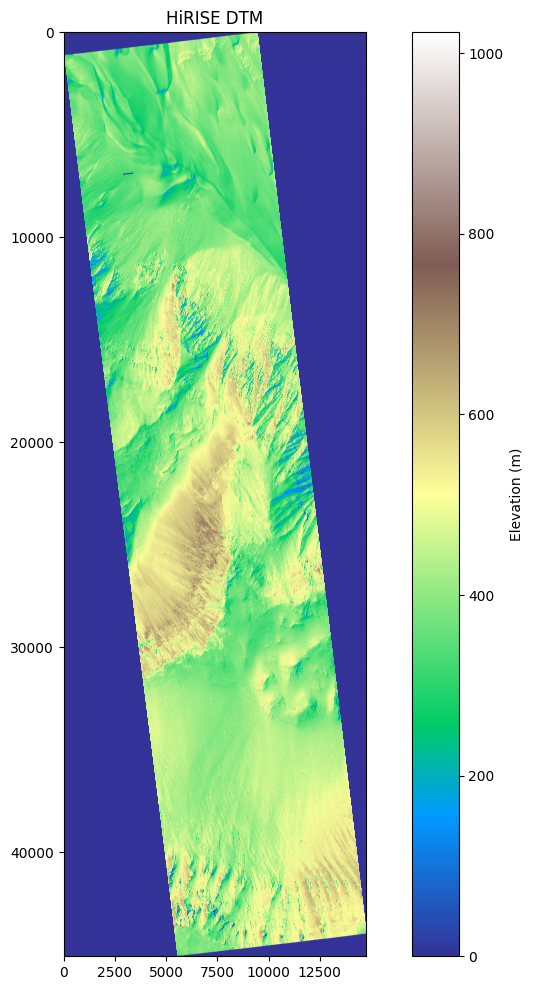

In [16]:
filepath = "data/DTMs/ESP_043599_1650_RED.JP2"
dtm_file = HiriseDTM(filepath)
print(dtm_file.metadata)

dtm_file.plot_dtm()

In [17]:
dtm_file.get_lat_lon(0, 0)

(-14.857495014916, 302.95897677796)